In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features

In [2]:
torch.manual_seed(42)
device = torch.device(
                    "cuda"
                    if torch.cuda.is_available()
                    else "mps" if torch.backends.mps.is_available() else "cpu"
                )
print(f"Using {device}")

# load & preprocess
data = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data['x'].T)
labs  = pd.DataFrame(data['y'].T, columns=['y'])
df = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)


Using mps


In [3]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="raw")
print(data.get_samples().shape, data.get_labels().shape)

(3309, 36000) (3309,)


[INFO] EPOCH: 1/25
Train loss: 0.630172, Train accuracy: 0.6610
[INFO] EPOCH: 2/25
Train loss: 0.538513, Train accuracy: 0.6923
[INFO] EPOCH: 3/25
Train loss: 0.449885, Train accuracy: 0.7943
[INFO] EPOCH: 4/25
Train loss: 0.381304, Train accuracy: 0.8317
[INFO] EPOCH: 5/25
Train loss: 0.353066, Train accuracy: 0.8490
[INFO] EPOCH: 6/25
Train loss: 0.305309, Train accuracy: 0.8733
[INFO] EPOCH: 7/25
Train loss: 0.284579, Train accuracy: 0.8880
[INFO] EPOCH: 8/25
Train loss: 0.244028, Train accuracy: 0.9067
[INFO] EPOCH: 9/25
Train loss: 0.241968, Train accuracy: 0.9057
[INFO] EPOCH: 10/25
Train loss: 0.202240, Train accuracy: 0.9260
[INFO] EPOCH: 11/25
Train loss: 0.174425, Train accuracy: 0.9310
[INFO] EPOCH: 12/25
Train loss: 0.154574, Train accuracy: 0.9497
[INFO] EPOCH: 13/25
Train loss: 0.135208, Train accuracy: 0.9537
[INFO] EPOCH: 14/25
Train loss: 0.108826, Train accuracy: 0.9607
[INFO] EPOCH: 15/25
Train loss: 0.101646, Train accuracy: 0.9643
[INFO] EPOCH: 16/25
Train loss: 0.

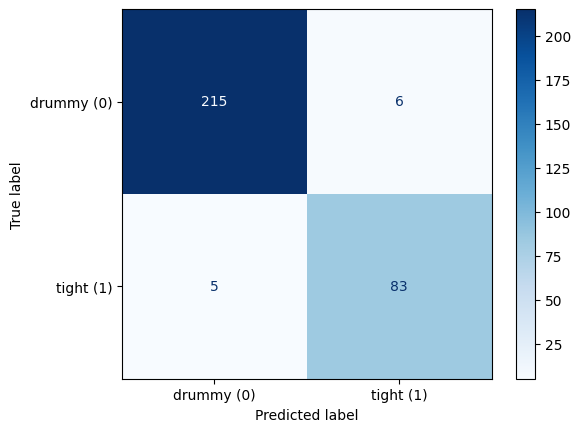


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.98      0.97      0.98       221
   tight (1)       0.93      0.94      0.94        88

    accuracy                           0.96       309
   macro avg       0.95      0.96      0.96       309
weighted avg       0.96      0.96      0.96       309



In [4]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=25)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

In [2]:
# Load the data
data_2 = sio.loadmat('../data/phase2_data_20220215.mat')
samps_2 = pd.DataFrame(data_2['x'].T)
labs_2  = pd.DataFrame(data_2['y'].T, columns=['y'])

# Combine and drop any NaNs
df_2 = pd.concat([samps_2, labs_2], axis=1).dropna()

# Padding function
def pad_audio(audio, target_length=36000):
    audio = np.asarray(audio, dtype=np.float32)
    padded = np.zeros(target_length, dtype=np.float32)
    padded[:min(len(audio), target_length)] = audio[:target_length]
    return padded
from scipy.signal import resample
def upsample_audio(audio, target_length=18000):
    return resample(audio, target_length)

# Pad all audio samples before shuffling
padded_samples = df_2.iloc[:, :-1].apply(lambda row: upsample_audio(row.values), axis=1)
df_2_X = pd.DataFrame(padded_samples.tolist())  # convert list of arrays to DataFrame
df_Y = df_2.iloc[:, -1].reset_index(drop=True)

# Combine and shuffle
df_all = pd.concat([df_2_X, df_Y], axis=1)
shuffled_df = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

# Split again
df_2_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

# Feature extraction
data_2 = Extract_Features(df_2_X, df_Y, feature="raw")
print(data_2.get_samples().shape, data_2.get_labels().shape)

(8440, 18000) (8440,)


[INFO] EPOCH: 1/20
Train loss: 0.696804, Train accuracy: 0.5482
[INFO] EPOCH: 2/20
Train loss: 0.652401, Train accuracy: 0.5933
[INFO] EPOCH: 3/20
Train loss: 0.568011, Train accuracy: 0.6991
[INFO] EPOCH: 4/20
Train loss: 0.546392, Train accuracy: 0.7076
[INFO] EPOCH: 5/20
Train loss: 0.514806, Train accuracy: 0.7366
[INFO] EPOCH: 6/20
Train loss: 0.497482, Train accuracy: 0.7557
[INFO] EPOCH: 7/20
Train loss: 0.480790, Train accuracy: 0.7672
[INFO] EPOCH: 8/20
Train loss: 0.456758, Train accuracy: 0.7818
[INFO] EPOCH: 9/20
Train loss: 0.450626, Train accuracy: 0.7813
[INFO] EPOCH: 10/20
Train loss: 0.415926, Train accuracy: 0.8080
[INFO] EPOCH: 11/20
Train loss: 0.405440, Train accuracy: 0.8084
[INFO] EPOCH: 12/20
Train loss: 0.386218, Train accuracy: 0.8221
[INFO] EPOCH: 13/20
Train loss: 0.365936, Train accuracy: 0.8341
[INFO] EPOCH: 14/20
Train loss: 0.353004, Train accuracy: 0.8383
[INFO] EPOCH: 15/20
Train loss: 0.326506, Train accuracy: 0.8566
[INFO] EPOCH: 16/20
Train loss: 0.

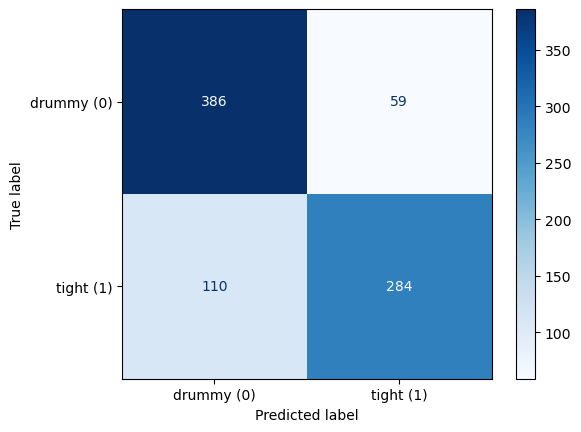


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.78      0.87      0.82       445
   tight (1)       0.83      0.72      0.77       394

    accuracy                           0.80       839
   macro avg       0.80      0.79      0.80       839
weighted avg       0.80      0.80      0.80       839



In [4]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7600))
test_idx = list(range(7600,8439))

train_data = torch.utils.data.Subset(data_2, train_idx)
test_data = torch.utils.data.Subset(data_2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3,weight_decay=1e-3, optim="adam", epochs=20)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)